# 📊 Customer Churn Prediction — Phase 1: EDA

**Dataset:** Telco Customer Churn (IBM Watson / Kaggle)  
**Goal:** Understand the data, identify churn patterns, and prepare insights for modeling  
**Author:** Muhammad Danu Firjatullah Rachman

---


## 1. Setup & Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print("Libraries loaded ✓")


Libraries loaded ✓


## 2. Load Dataset

Download from Kaggle: [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
Place `WA_Fn-UseC_-Telco-Customer-Churn.csv` in the same directory as this notebook.


In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()


Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Basic Data Inspection

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Fix TotalCharges — loaded as object due to whitespace
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop customerID (not a feature)
df = df.drop(columns=['customerID'])

# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values:")
print(missing if len(missing) > 0 else "None found ✓")


Missing values:
TotalCharges    11
dtype: int64


In [5]:
# Statistical summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,7043,3,No,3088,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Target Variable: Churn Distribution

Understanding class imbalance is critical — it affects model choice and evaluation metrics.


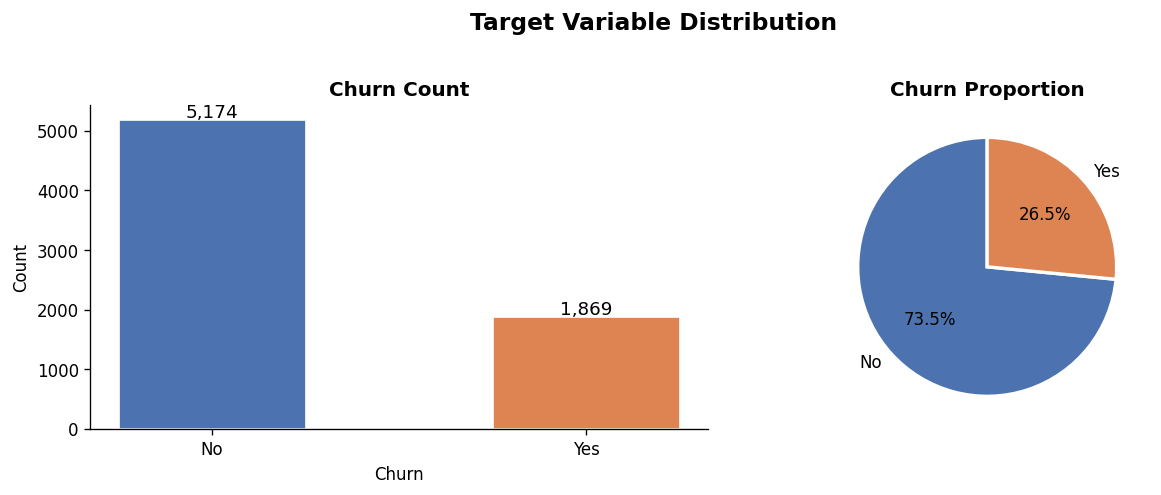


Churn rate: 26.5% — class imbalance present, will use class_weight or SMOTE in modeling.


In [6]:
# Encode target for easier use
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=['#4C72B0', '#DD8452'], width=0.5, edgecolor='white')
axes[0].set_title('Churn Count', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(churn_pct.values, labels=churn_pct.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Proportion', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/01_churn_distribution.png', bbox_inches='tight')
plt.show()

print(f"\nChurn rate: {churn_pct['Yes']:.1f}% — class imbalance present, will use class_weight or SMOTE in modeling.")


## 5. Numerical Feature Analysis

Key numerical features: `tenure`, `MonthlyCharges`, `TotalCharges`


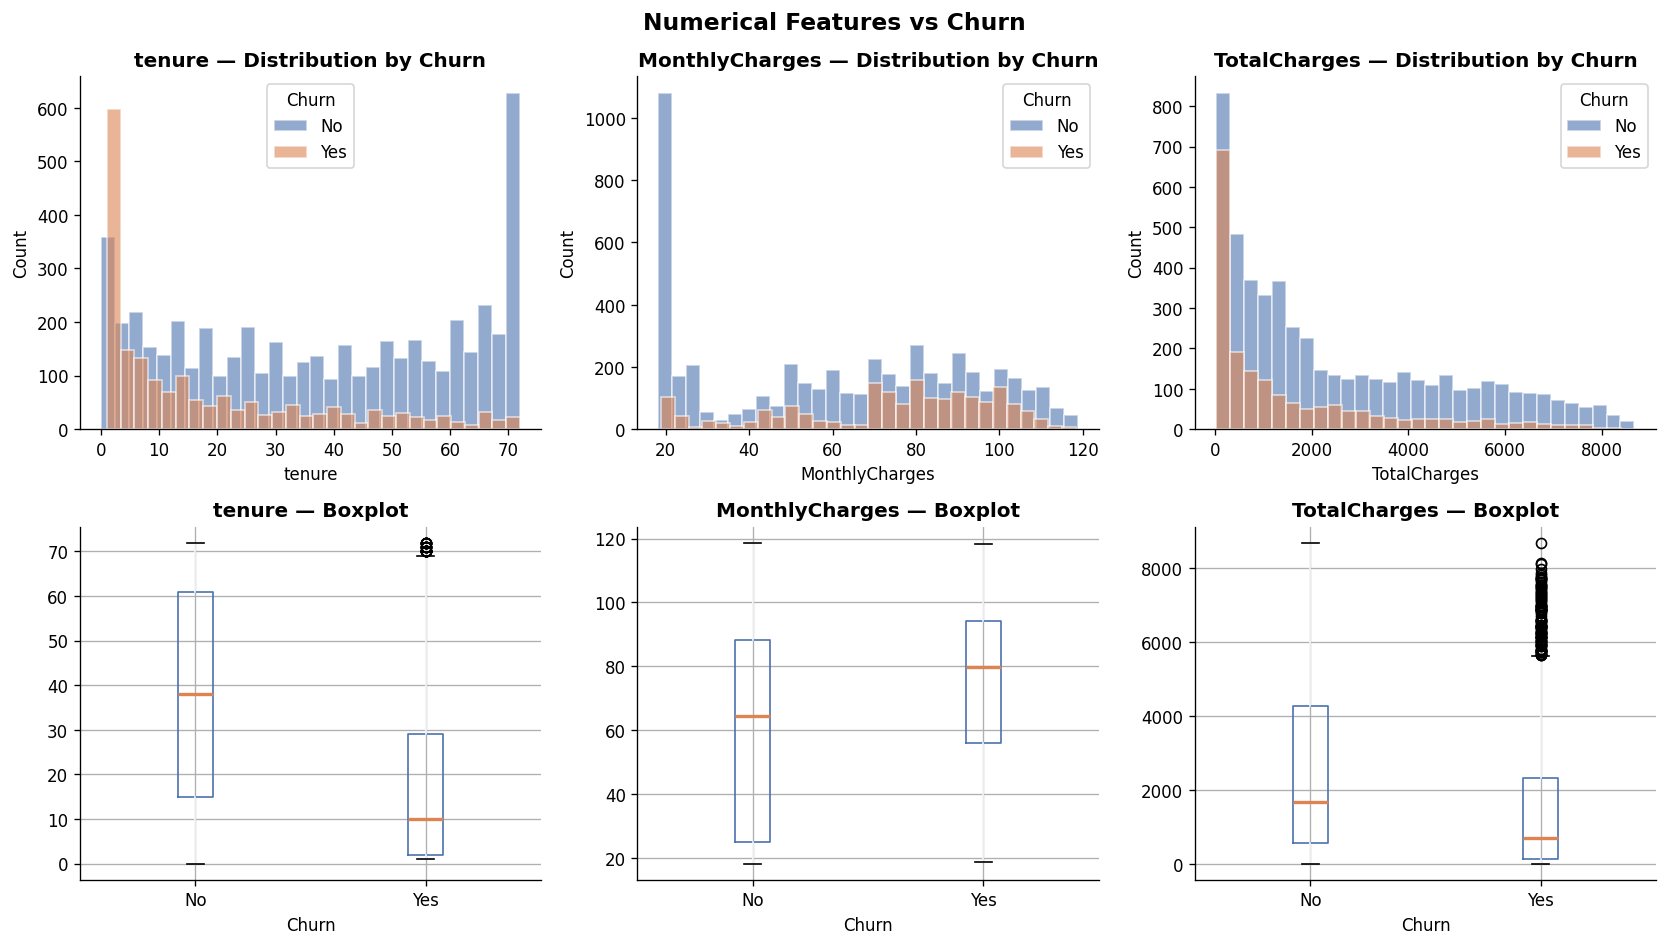

In [7]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(num_cols):
    # Distribution by churn
    for label, color in zip(['No', 'Yes'], ['#4C72B0', '#DD8452']):
        subset = df[df['Churn'] == label][col].dropna()
        axes[0, i].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[0, i].set_title(f'{col} — Distribution by Churn', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')
    axes[0, i].legend(title='Churn')

    # Boxplot
    df.boxplot(column=col, by='Churn', ax=axes[1, i],
               boxprops=dict(color='#4C72B0'),
               medianprops=dict(color='#DD8452', linewidth=2))
    axes[1, i].set_title(f'{col} — Boxplot', fontweight='bold')
    axes[1, i].set_xlabel('Churn')
    plt.sca(axes[1, i])
    plt.title(f'{col} — Boxplot', fontweight='bold')

plt.suptitle('Numerical Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/02_numerical_features.png', bbox_inches='tight')
plt.show()


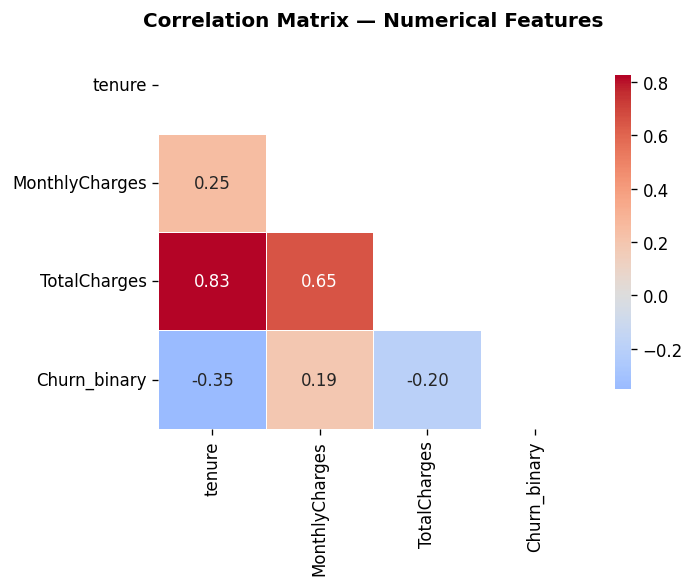

In [8]:
# Correlation matrix — numerical only
corr = df[num_cols + ['Churn_binary']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/03_correlation_matrix.png', bbox_inches='tight')
plt.show()

## 6. Categorical Feature Analysis

We examine churn rate per category to identify high-risk segments.


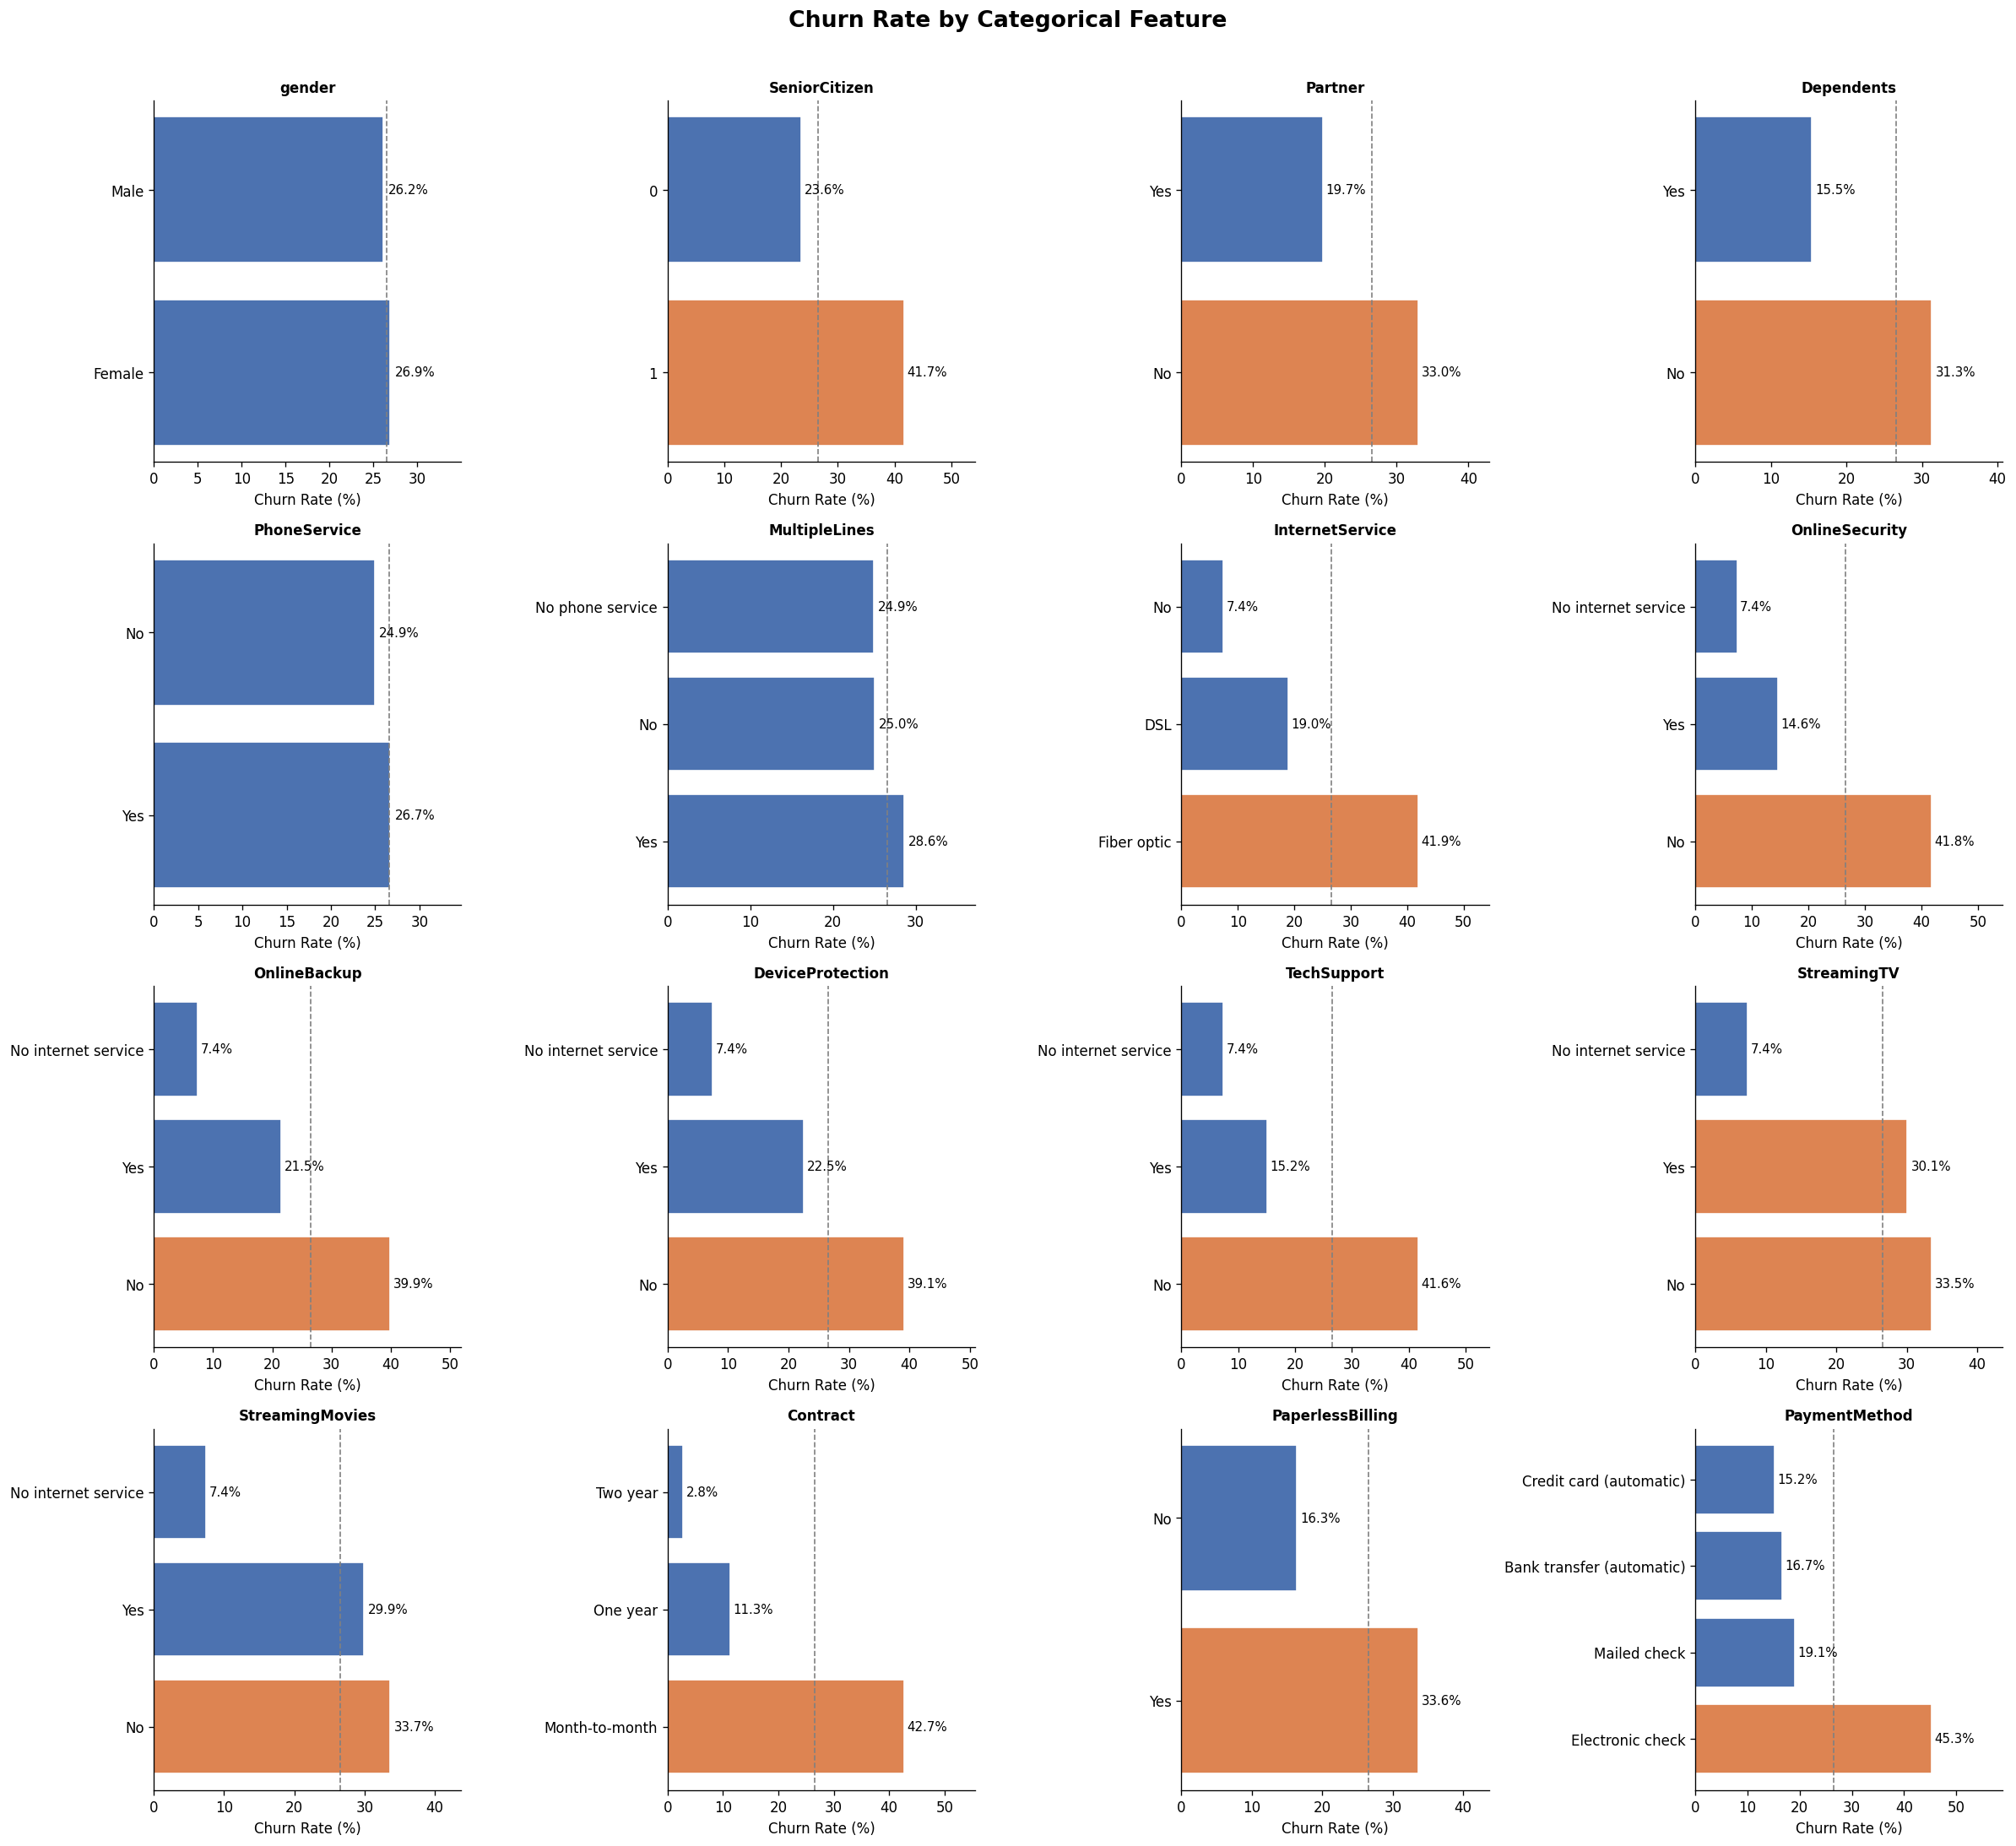

In [9]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Compute churn rate per category
def churn_rate_plot(df, col, ax):
    ct = df.groupby(col)['Churn_binary'].mean().sort_values(ascending=False) * 100
    colors = ['#DD8452' if v > 30 else '#4C72B0' for v in ct.values]
    bars = ax.barh(ct.index.astype(str), ct.values, color=colors, edgecolor='white')
    ax.axvline(x=df['Churn_binary'].mean()*100, color='gray',
               linestyle='--', linewidth=1, label='Overall avg')
    ax.set_xlabel('Churn Rate (%)')
    ax.set_title(col, fontweight='bold', fontsize=10)
    for bar, val in zip(bars, ct.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.set_xlim(0, ct.max() * 1.3)

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate_plot(df, col, axes[i])

plt.suptitle('Churn Rate by Categorical Feature', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../plots/04_categorical_features.png', bbox_inches='tight')
plt.show()


## 7. Deep-Dive: High-Risk Segments

Focus on features with the strongest churn signal.


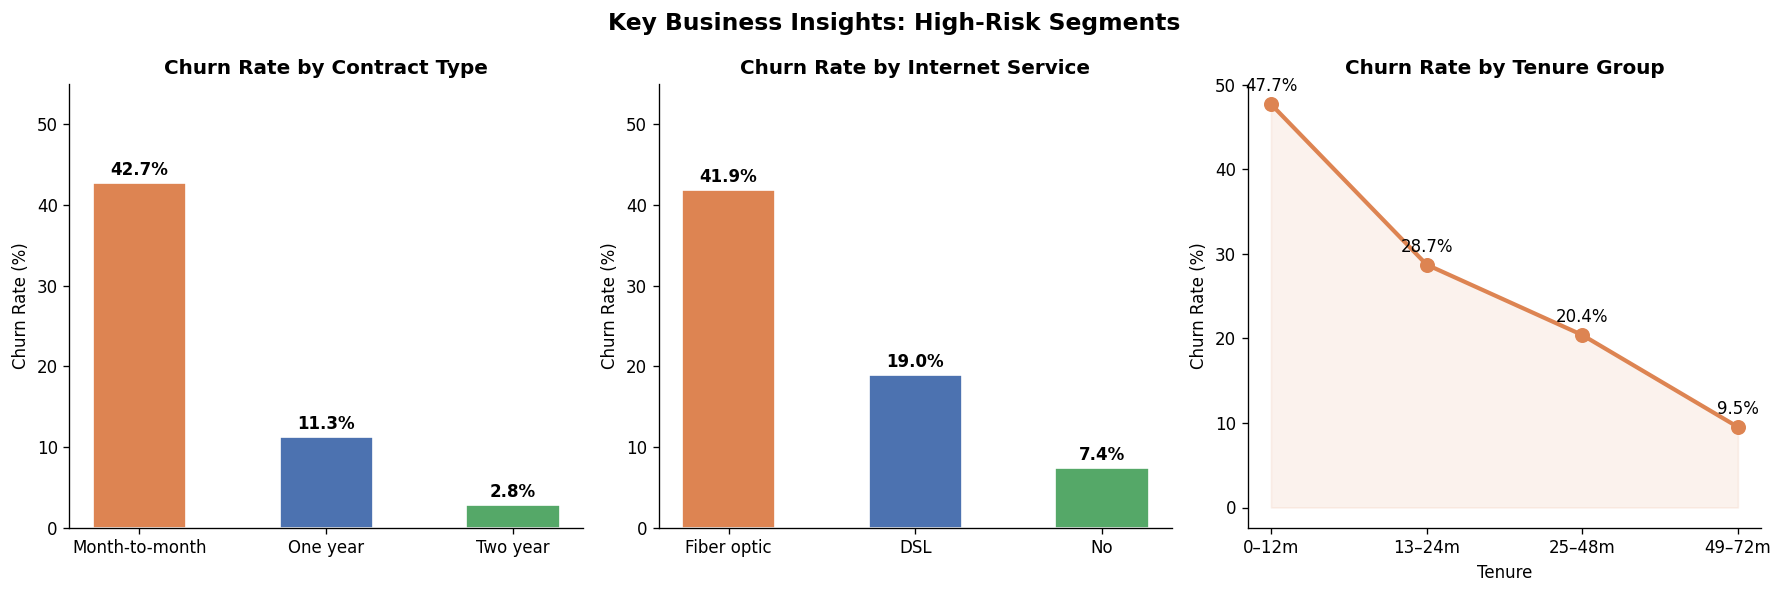

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Contract type
ct = df.groupby('Contract')['Churn_binary'].mean().sort_values(ascending=False) * 100
axes[0].bar(ct.index, ct.values, color=['#DD8452', '#4C72B0', '#55A868'], edgecolor='white', width=0.5)
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 55)
for i, (x, v) in enumerate(zip(ct.index, ct.values)):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Internet service
ct2 = df.groupby('InternetService')['Churn_binary'].mean().sort_values(ascending=False) * 100
axes[1].bar(ct2.index, ct2.values, color=['#DD8452', '#4C72B0', '#55A868'], edgecolor='white', width=0.5)
axes[1].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 55)
for i, (x, v) in enumerate(zip(ct2.index, ct2.values)):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Tenure buckets
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                             labels=['0–12m', '13–24m', '25–48m', '49–72m'])
ct3 = df.groupby('tenure_group', observed=True)['Churn_binary'].mean() * 100
axes[2].plot(ct3.index.astype(str), ct3.values, marker='o', color='#DD8452',
             linewidth=2.5, markersize=8)
axes[2].fill_between(range(len(ct3)), ct3.values, alpha=0.1, color='#DD8452')
axes[2].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_xlabel('Tenure')
for i, v in enumerate(ct3.values):
    axes[2].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Key Business Insights: High-Risk Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/05_key_segments.png', bbox_inches='tight')
plt.show()


## 8. Monthly Charges vs Tenure — Churn Pattern

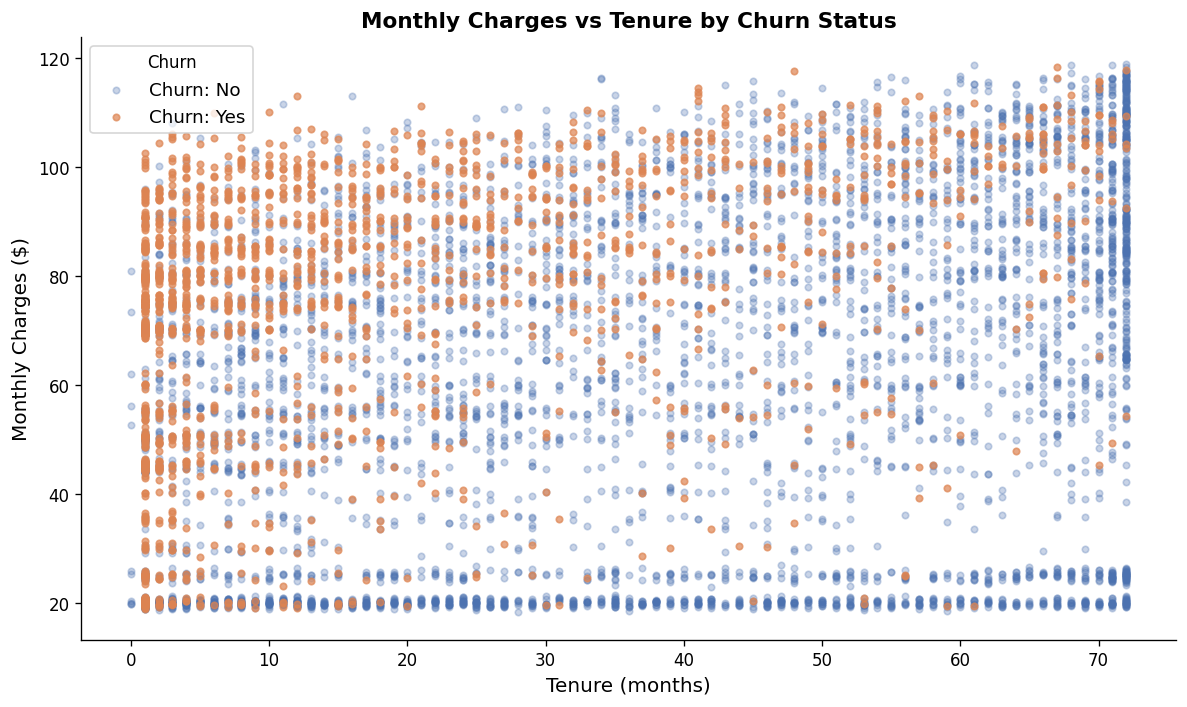

Insight: Churners tend to cluster at low tenure + high monthly charges — short-term, high-cost customers.


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, color, alpha in zip(['No', 'Yes'], ['#4C72B0', '#DD8452'], [0.3, 0.7]):
    subset = df[df['Churn'] == label]
    ax.scatter(subset['tenure'], subset['MonthlyCharges'],
               c=color, alpha=alpha, s=15, label=f'Churn: {label}')

ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Monthly Charges ($)', fontsize=12)
ax.set_title('Monthly Charges vs Tenure by Churn Status', fontweight='bold', fontsize=13)
ax.legend(title='Churn', fontsize=11)
plt.tight_layout()
plt.savefig('../plots/06_scatter_tenure_charges.png', bbox_inches='tight')
plt.show()

print("Insight: Churners tend to cluster at low tenure + high monthly charges — short-term, high-cost customers.")


## 9. EDA Summary & Business Insights

### Key Findings

| Finding | Detail |
|---|---|
| **Class imbalance** | ~26% churn rate — need SMOTE or `class_weight='balanced'` in modeling |
| **Contract type** | Month-to-month customers churn at ~42%, vs <5% for 2-year contracts |
| **Tenure** | Customers in first 12 months have highest churn risk |
| **Internet service** | Fiber optic users churn more than DSL — possibly price sensitivity |
| **Monthly charges** | Churners have significantly higher monthly charges (median ~$80 vs $65) |
| **No online security/backup** | These features strongly correlate with lower churn |

### Feature Engineering Candidates (for Phase 2)
- `has_support_services`: binary — has TechSupport OR OnlineSecurity
- `is_month_to_month`: binary from Contract
- `charge_per_month_tenure`: MonthlyCharges / (tenure + 1) — cost efficiency proxy
- `num_streaming_services`: sum of StreamingTV + StreamingMovies

### Next Steps → Phase 2
- Feature engineering based on insights above
- Encode categoricals (OrdinalEncoder / OneHotEncoder via sklearn Pipeline)
- Train Logistic Regression (baseline), Random Forest, XGBoost
- Evaluate with ROC-AUC, F1-score, Precision-Recall curve
- SHAP explainability on best model


## 10. Save Preprocessed Data

In [12]:
import os
df.to_csv('../data/processed/telco_eda_clean.csv', index=False)
print(f"Saved: data/processed/telco_eda_clean.csv — shape {df.shape}")
print("\nPhase 1 complete ✓  →  Proceed to 02-modeling.ipynb")

Saved: data/processed/telco_eda_clean.csv — shape (7043, 22)

Phase 1 complete ✓  →  Proceed to 02-modeling.ipynb
